<a href="https://colab.research.google.com/github/Bhargava-007/Machine-Learning-2-1/blob/main/Exp_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

uploaded = files.upload()

Saving placement_predict_50k_Dataset.csv to placement_predict_50k_Dataset (1).csv


In [6]:
df = pd.read_csv("placement_predict_50k_Dataset.csv")

print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nPlacementStatus counts:\n", df["PlacementStatus"].value_counts())
print("\nCGPA_Tier counts:\n", df["CGPA_Tier"].value_counts())
df.head()

Dataset shape: (50000, 32)

Missing values:
 Workshops             4488
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
dtype: int64

PlacementStatus counts:
 PlacementStatus
1    32856
0    17144
Name: count, dtype: int64

CGPA_Tier counts:
 CGPA_Tier
Low     16733
High    16681
Mid     16586
Name: count, dtype: int64


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [7]:
exclude_cols = [
    "PlacementStatus",
    "CGPA_Tier",
    "Salary Package",
    "StudentID",
    "IsAnomaly"
]

X = df.drop(columns=exclude_cols, errors="ignore")
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [8]:
def evaluate_classifier(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_accuracy = accuracy_score(y_train, train_pred)
    val_accuracy = accuracy_score(y_val, val_pred)

    print("=" * 70)
    print("MODEL EVALUATION")
    print("=" * 70)
    print(f"\nTrain Accuracy     : {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, val_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, val_pred))

    return {
        "model": model,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_predictions": train_pred,
        "val_predictions": val_pred
    }

In [9]:
y_binary = df["PlacementStatus"]

X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(
    X, y_binary, test_size=0.20, random_state=42, stratify=y_binary
)

binary_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

binary_result = evaluate_classifier(
    binary_lr, X_train_bin, y_train_bin, X_val_bin, y_val_bin
)

MODEL EVALUATION

Train Accuracy     : 0.9257
Validation Accuracy: 0.9198

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3429
           1       0.93      0.95      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.90      0.91     10000
weighted avg       0.92      0.92      0.92     10000

Confusion Matrix:
[[2928  501]
 [ 301 6270]]


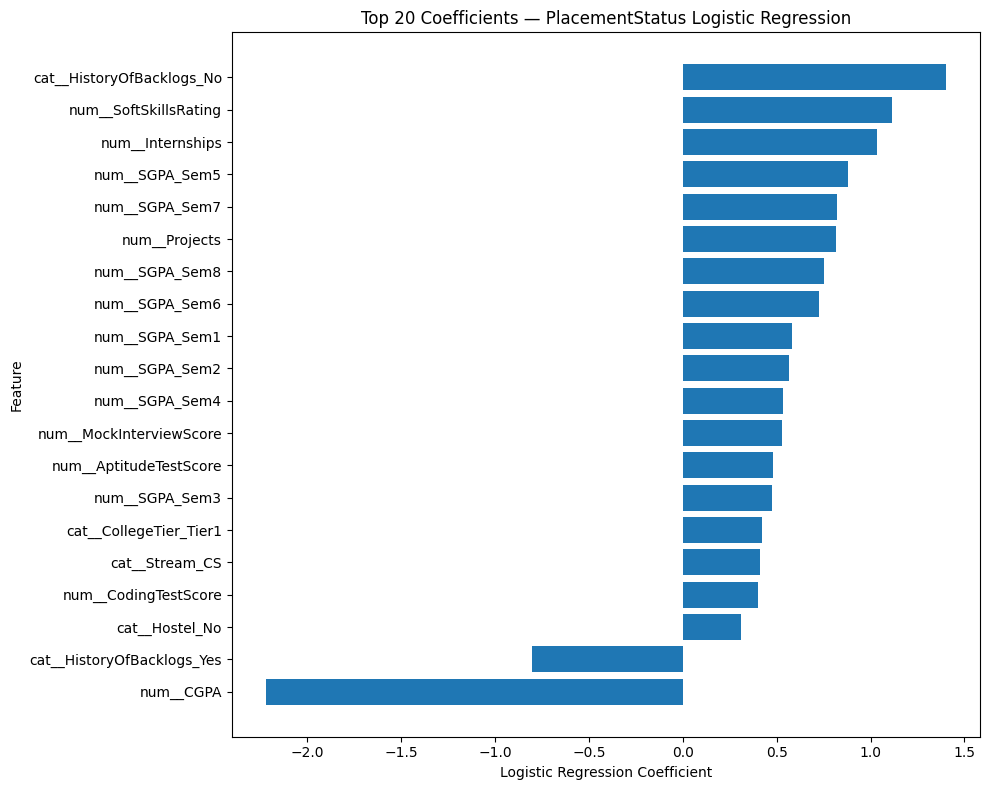

In [10]:
feature_names_binary = binary_lr.named_steps["preprocessor"].get_feature_names_out()
coefficients_binary = binary_lr.named_steps["classifier"].coef_[0]

coef_binary_df = pd.DataFrame({
    "Feature": feature_names_binary,
    "Coefficient": coefficients_binary
})
coef_binary_df["AbsoluteCoefficient"] = coef_binary_df["Coefficient"].abs()
coef_binary_df = coef_binary_df.sort_values("AbsoluteCoefficient", ascending=False)

top20_binary = coef_binary_df.head(20).sort_values("Coefficient")

plt.figure(figsize=(10, 8))
plt.barh(top20_binary["Feature"], top20_binary["Coefficient"])
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 20 Coefficients — PlacementStatus Logistic Regression")
plt.tight_layout()
plt.show()

In [11]:
y_multi = df["CGPA_Tier"]

X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(
    X, y_multi, test_size=0.20, random_state=42, stratify=y_multi
)

multi_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42))
])

multi_result = evaluate_classifier(
    multi_lr, X_train_multi, y_train_multi, X_val_multi, y_val_multi
)

MODEL EVALUATION

Train Accuracy     : 0.9682
Validation Accuracy: 0.9692

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.97      0.98      3336
         Low       0.98      0.98      0.98      3347
         Mid       0.95      0.96      0.95      3317

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

Confusion Matrix:
[[3249    0   87]
 [   0 3275   72]
 [  74   75 3168]]


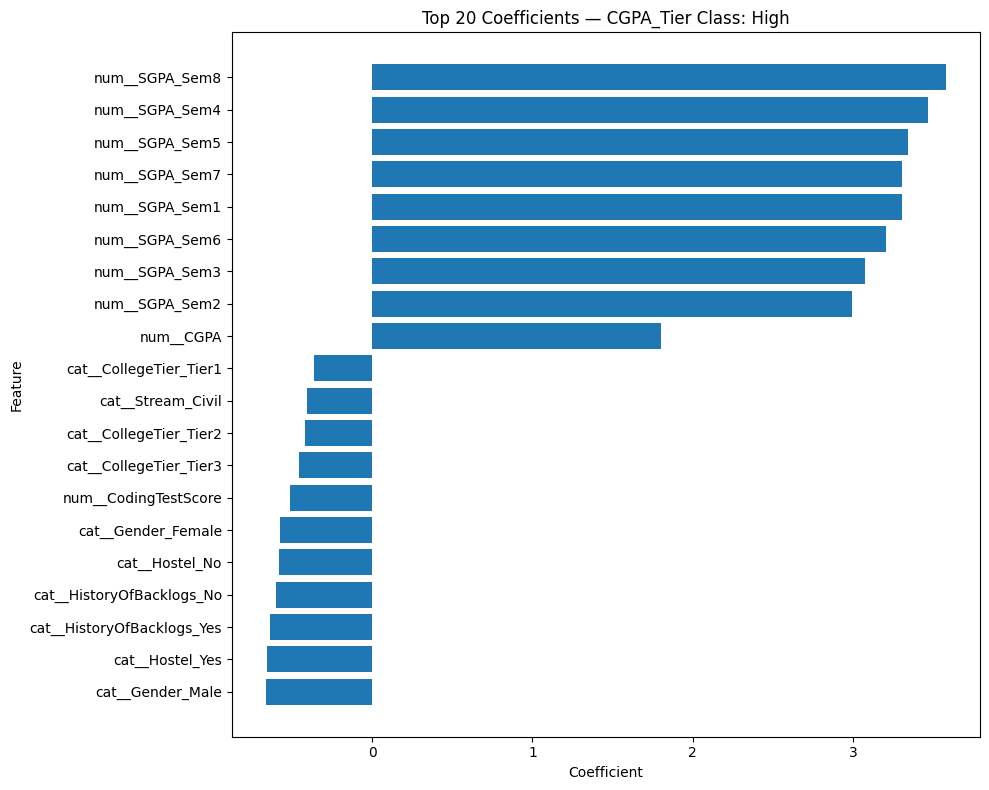

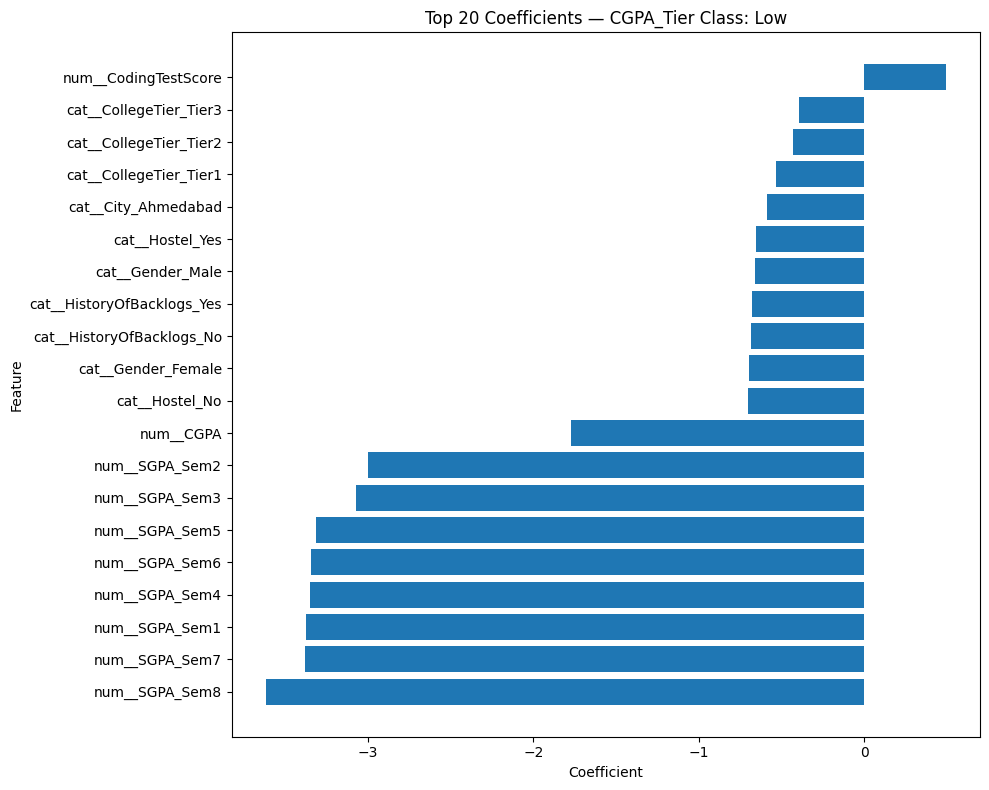

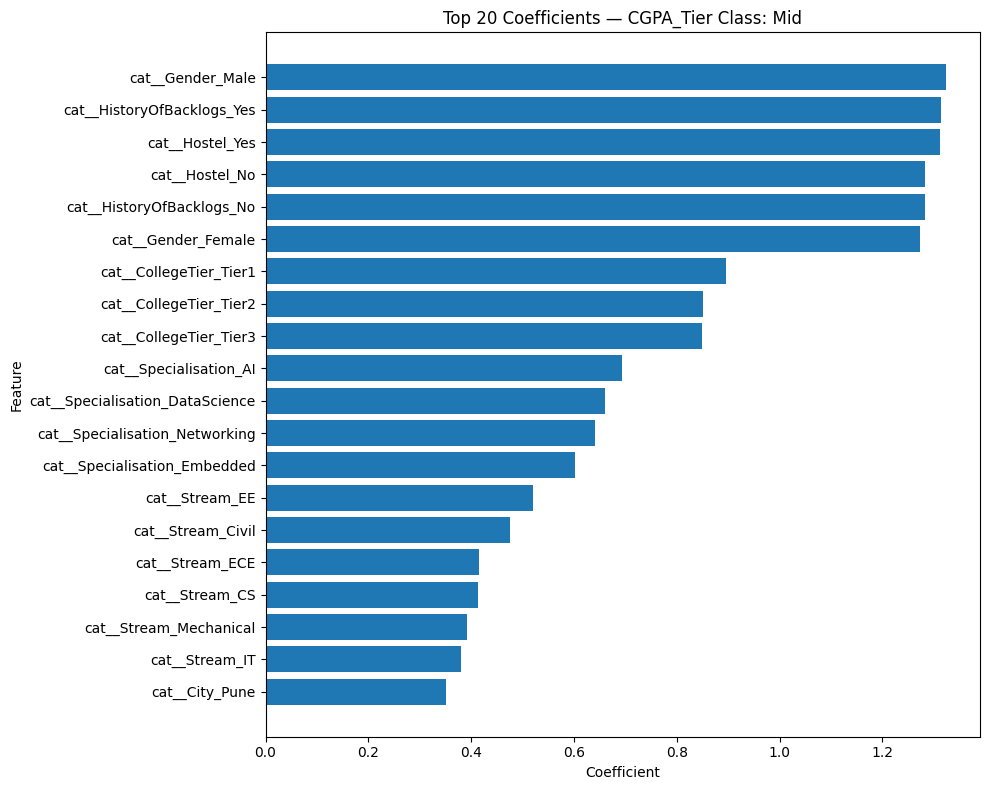

In [12]:
feature_names_multi = multi_lr.named_steps["preprocessor"].get_feature_names_out()
multi_coefficients = multi_lr.named_steps["classifier"].coef_
classes = multi_lr.named_steps["classifier"].classes_

for i, class_label in enumerate(classes):
    coef_df = pd.DataFrame({
        "Feature": feature_names_multi,
        "Coefficient": multi_coefficients[i]
    })
    coef_df["AbsoluteCoefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values("AbsoluteCoefficient", ascending=False)

    top20 = coef_df.head(20).sort_values("Coefficient")

    plt.figure(figsize=(10, 8))
    plt.barh(top20["Feature"], top20["Coefficient"])
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title(f"Top 20 Coefficients — CGPA_Tier Class: {class_label}")
    plt.tight_layout()
    plt.show()

In [13]:
academic_features = [
    "SGPA_Sem1", "SGPA_Sem2", "SGPA_Sem3", "SGPA_Sem4", "SGPA_Sem5",
    "SGPA_Sem6", "SGPA_Sem7", "SGPA_Sem8", "CGPA", "AttendancePercent",
    "Internships", "Projects", "Workshops", "Certifications",
    "Publications", "AptitudeTestScore", "SoftSkillsRating",
    "CodingTestScore", "MockInterviewScore"
]

X_academic = df[academic_features]
y_academic = df["PlacementStatus"]

X_train_acad, X_val_acad, y_train_acad, y_val_acad = train_test_split(
    X_academic, y_academic, test_size=0.20, random_state=42, stratify=y_academic
)

academic_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

academic_lr = Pipeline(steps=[
    ("preprocessor", academic_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

academic_result = evaluate_classifier(
    academic_lr, X_train_acad, y_train_acad, X_val_acad, y_val_acad
)

MODEL EVALUATION

Train Accuracy     : 0.9159
Validation Accuracy: 0.9090

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      3429
           1       0.92      0.95      0.93      6571

    accuracy                           0.91     10000
   macro avg       0.90      0.89      0.90     10000
weighted avg       0.91      0.91      0.91     10000

Confusion Matrix:
[[2862  567]
 [ 343 6228]]


In [14]:
results_df = pd.DataFrame({
    "Model": [
        "Binary PlacementStatus LR",
        "Multinomial CGPA_Tier LR",
        "Academic PlacementStatus LR"
    ],
    "Train Accuracy": [
        binary_result["train_accuracy"],
        multi_result["train_accuracy"],
        academic_result["train_accuracy"]
    ],
    "Validation Accuracy": [
        binary_result["val_accuracy"],
        multi_result["val_accuracy"],
        academic_result["val_accuracy"]
    ]
})

results_df

,Model,Train Accuracy,Validation Accuracy
0,Binary PlacementStatus LR,0.92575,0.9198
1,Multinomial CGPA_Tier LR,0.96820,0.9692
2,Academic PlacementStatus LR,0.91585,0.9090
